In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from scipy.signal import welch, stft, spectrogram, butter, sosfiltfilt

In [3]:
while True:
    filepath = input("Enter the absolute path to lvm file: ").strip().strip('"')
    if os.path.isfile(filepath):
        break
    print("Invalid file. Try again.")

print(f"Using file: {filepath}")

start_line = None
with open(filepath, "r") as f:
    for i, line in enumerate(f):
        if line.strip().startswith("X_Value"):
            start_line = i + 1
            break

if start_line is None:
    raise ValueError("Couldn't find the 'X_Value' header line in the file.")

data = np.loadtxt(
    filepath,
    delimiter=",",
    skiprows=start_line,
    usecols=(0, 1),
)

# Normalize the raw signal by removing the mean to center it around zero
data[:, 1] -= data[:, 1].mean()

print(data.shape)
sampling_frequency = 1 / np.mean(np.diff(data[:, 0]))
print(f"Estimated sampling frequency: {sampling_frequency:.2f} Hz")

# Print first few rows as a table
n_preview = 10
print(f"\n{'Row':<6} {'Time (s)':>14} {'Voltage (V)':>14}")
print("-" * 36)
for i in range(n_preview):
    print(f"{i:<6} {data[i, 0]:>14.6f} {data[i, 1]:>14.6f}")

def highpass_filter(signal, cutoff_hz, fs, order=4):
    sos = butter(order, cutoff_hz, btype='high', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

# # High-pass filter to remove frequencies below a cutoff frequency
# cutoff_freq = 600.0  # Hz
# data[:, 1] = highpass_filter(data[:, 1], cutoff_freq, sampling_frequency)

Using file: C:\Users\sapierso\Downloads\hydrophone_test_33.lvm
(3840000, 2)
Estimated sampling frequency: 12800.00 Hz

Row          Time (s)    Voltage (V)
------------------------------------
0            0.000000      -0.002125
1            0.000078      -0.002016
2            0.000156      -0.002110
3            0.000234      -0.002219
4            0.000312      -0.002178
5            0.000391      -0.002186
6            0.000469      -0.002377
7            0.000547      -0.002464
8            0.000625      -0.002663
9            0.000703      -0.003054


Sxx_log shape: (4097, 936)
Masked Sxx_log shape: (3841, 936)
Minimum Spectrogram Power: -120
Maximum Spectrogram Power: -40


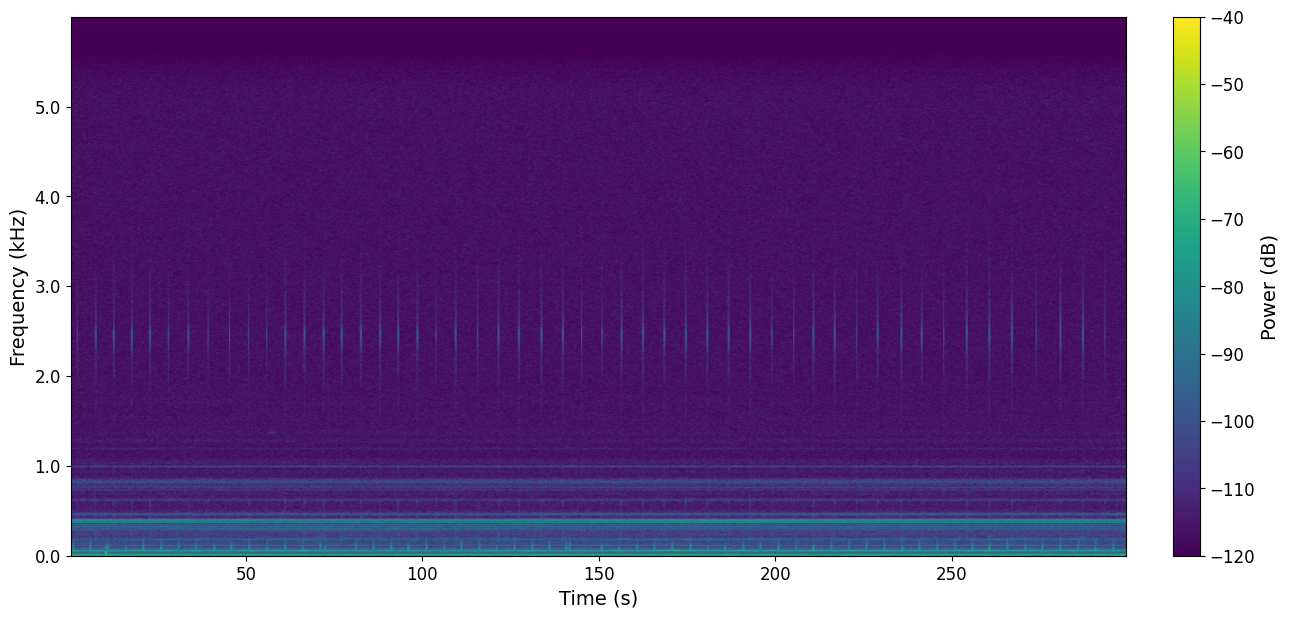

In [4]:
# Compute the spectrogram
nperseg = 4096 * 2
noverlap = nperseg // 2
frequencies, times, Sxx = spectrogram(
    data[:, 1],
    sampling_frequency,
    scaling='spectrum',
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx_log = 10 * np.log10(Sxx)

max_freq = 6e3  # Frequency (Hz) over which to mask out the y-axis
freq_mask = frequencies <= max_freq
masked_frequencies = frequencies[freq_mask]
masked_Sxx_log = Sxx_log[freq_mask, :]

start_time_mask = 0
end_time_mask = start_time_mask + 60*60
time_mask = (times >= start_time_mask) & (times <= end_time_mask)
masked_times = times[time_mask]
masked_Sxx_log = masked_Sxx_log[:, time_mask]

# min_spectrogram_value_ctrl = psd_db_min
# max_spectrogram_value_ctrl = psd_db_max
max_spectrogram_value_ctrl = -40
min_spectrogram_value_ctrl = -120

print(f"Sxx_log shape: {Sxx_log.shape}")
print(f"Masked Sxx_log shape: {masked_Sxx_log.shape}")


fig, ax1 = plt.subplots(figsize=(16, 7))

label_size=14
tick_size=12

print("Minimum Spectrogram Power:", min_spectrogram_value_ctrl)
print("Maximum Spectrogram Power:", max_spectrogram_value_ctrl)

# TODO: If want log scale, need to transform the masked_power_db array (harder, more memory-efficient) or use pcolormesh (easier)
spectrogram_image = ax1.imshow(
    masked_Sxx_log,
    extent=[masked_times[0], masked_times[-1], masked_frequencies[-1]/1e3, masked_frequencies[0]/1e3], 
    interpolation='bilinear', 
    cmap='viridis', 
    aspect='auto', 
    vmin=min_spectrogram_value_ctrl,
    vmax=max_spectrogram_value_ctrl, 
    # origin='lower'
)
ax1.invert_yaxis()

ax1.set_ylabel('Frequency (kHz)', fontsize=label_size)
ax1.set_xlabel('Time (s)', fontsize=label_size)

# # Add dashed red horizontal line at strongest FFT frequency
# peak_frequency = 2.45e3  # Hz — replace with actual peak frequency
# ax1.axhline(
#     y=peak_frequency / 1e3,
#     color='red',
#     linestyle='--',
#     linewidth=2,
#     label=f'Peak FFT band: {peak_frequency:.2f} Hz'
# )

# Format the y-axis to show whole numbers instead of scientific notation
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))

# Adjust the space between the graph and colorbar
plt.subplots_adjust(right=0.85)  # Adjust right side to make room for colorbar

cbar = fig.colorbar(spectrogram_image, ax=[ax1], fraction=0.05, pad=0.04)
cbar.set_label('Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size) 

plt.tick_params(axis='both', which='major', labelsize=tick_size)

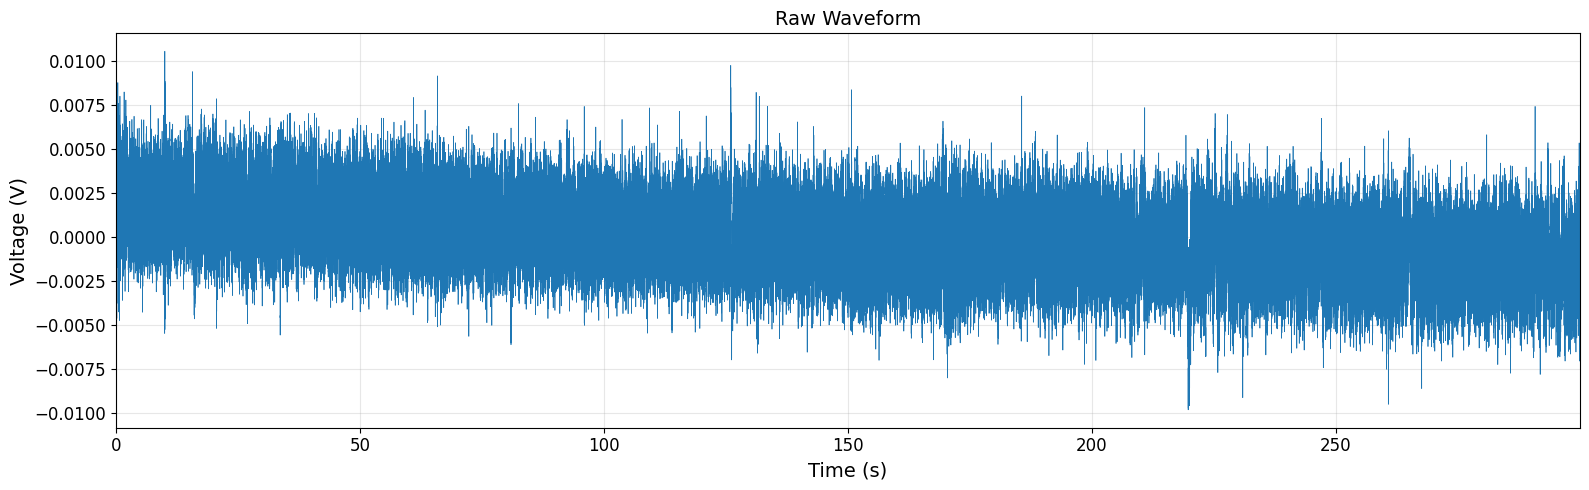

In [5]:
fig2, ax2 = plt.subplots(figsize=(16, 5))

ax2.plot(data[:, 0], data[:, 1], linewidth=0.5)
ax2.set_xlim(start_time_mask, min(end_time_mask, data[-1, 0]))
ax2.set_xlabel('Time (s)', fontsize=label_size)
ax2.set_ylabel('Voltage (V)', fontsize=label_size)
ax2.set_title('Raw Waveform', fontsize=label_size)
ax2.tick_params(axis='both', which='major', labelsize=tick_size)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

First threshold crossing at t = 0.0000 s (sample 0)


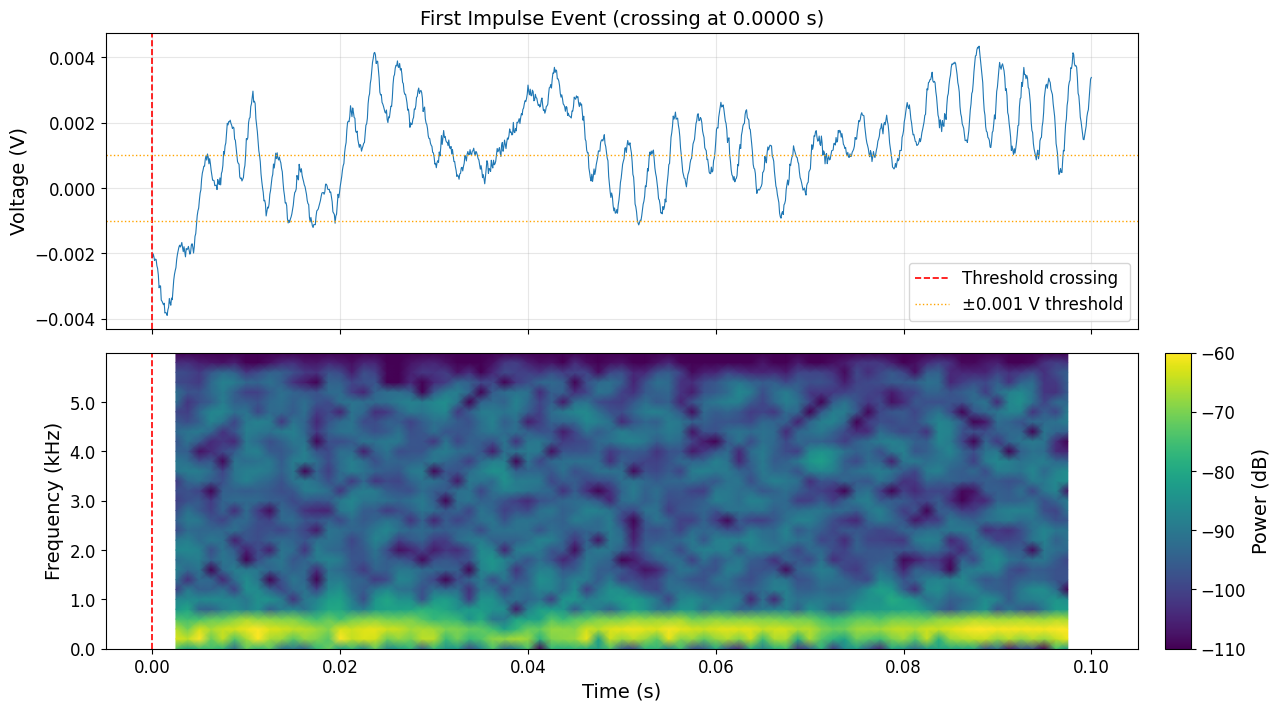

In [8]:
THRESHOLD = 0.001        # V
PRE_EVENT  = 0.1        # seconds before crossing
POST_EVENT = 0.1        # seconds after crossing

max_spectrogram_value_ctrl = -60
min_spectrogram_value_ctrl = -110

time   = data[:, 0]
signal = data[:, 1]

# Find first sample where |signal| exceeds threshold
crossing_indices = np.where(np.abs(data[:, 1]) > THRESHOLD)[0]

if len(crossing_indices) == 0:
    print("No threshold crossings found. Skipping impulse plot.")
else:
    idx = crossing_indices[0]
    t_event = time[idx]
    print(f"First threshold crossing at t = {t_event:.4f} s (sample {idx})")

    t_start = t_event - PRE_EVENT
    t_end   = t_event + POST_EVENT

    # Clamp to signal bounds
    t_start = max(t_start, time[0])
    t_end   = min(t_end,   time[-1])

    window_mask = (time >= t_start) & (time <= t_end)
    t_win = time[window_mask]
    s_win = signal[window_mask]

    fig3 = plt.figure(figsize=(14, 8))
    gs = fig3.add_gridspec(
        2, 2,
        width_ratios=[20, 0.5],   # narrow right column for colorbar
        height_ratios=[1, 1],
        hspace=0.08,            # tight vertical gap since x-axis is shared
        wspace=0.05,
    )

    ax3  = fig3.add_subplot(gs[0, 0])
    ax4  = fig3.add_subplot(gs[1, 0], sharex=ax3)
    cax  = fig3.add_subplot(gs[1, 1])  # colorbar spans only bottom row

    # --- Waveform ---
    ax3.plot(t_win, s_win, linewidth=0.8)
    ax3.axvline(t_event,    color='red',    linestyle='--', linewidth=1.2, label='Threshold crossing')
    ax3.axhline( THRESHOLD, color='orange', linestyle=':',  linewidth=1.0, label=f'±{THRESHOLD} V threshold')
    ax3.axhline(-THRESHOLD, color='orange', linestyle=':',  linewidth=1.0)
    ax3.set_ylabel('Voltage (V)', fontsize=label_size)
    ax3.set_title(f'First Impulse Event (crossing at {t_event:.4f} s)', fontsize=label_size)
    ax3.tick_params(axis='both', which='major', labelsize=tick_size)
    ax3.legend(fontsize=tick_size)
    ax3.grid(True, alpha=0.3)
    plt.setp(ax3.get_xticklabels(), visible=False)  # hide redundant x-ticks on top panel

    # --- Spectrogram ---
    NPERSEG = 64   # samples per FFT window — the primary tradeoff knob
    imp_freqs, imp_times, imp_Sxx = spectrogram(
        s_win,
        sampling_frequency,
        nperseg=NPERSEG,
        noverlap=NPERSEG // 4 * 3,   # 50%-75% overlap — reasonable default
        nfft=NPERSEG,            # no zero-padding; set higher (e.g. NPERSEG*4) to interpolate frequency bins
        window='hann',
        scaling='spectrum',
    )

    imp_times_abs  = imp_times + t_start
    imp_Sxx_log    = 10 * np.log10(imp_Sxx)

    freq_mask_imp  = imp_freqs <= max_freq
    imp_Sxx_plot   = imp_Sxx_log[freq_mask_imp, :]
    imp_freqs_plot = imp_freqs[freq_mask_imp]

    im = ax4.pcolormesh(
        imp_times_abs,
        imp_freqs_plot / 1e3,
        imp_Sxx_plot,
        cmap='viridis',
        vmin=min_spectrogram_value_ctrl,
        vmax=max_spectrogram_value_ctrl,
        shading='gouraud',
    )
    ax4.axvline(t_event, color='red', linestyle='--', linewidth=1.2)
    ax4.set_xlabel('Time (s)', fontsize=label_size)
    ax4.set_ylabel('Frequency (kHz)', fontsize=label_size)
    ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax4.tick_params(axis='both', which='major', labelsize=tick_size)

    # --- Colorbar in its own dedicated axis ---
    cbar3 = fig3.colorbar(im, cax=cax)
    cbar3.set_label('Power (dB)', fontsize=label_size)
    cbar3.ax.tick_params(labelsize=tick_size)

In [7]:
# # --- Spectrum mode selector ---
# # 1 = Normalised amplitude  : linear scale, intuitive y-axis, low freqs dominate visually
# # 2 = Normalised power      : squares amplitude, further suppresses high freqs — rarely ideal for comparison
# # 3 = dB power (recommended): log scale, equal visual emphasis across freq range, standard for acoustics
# SPECTRUM_MODE = 3


# def compute_spectrum(s_win, sampling_frequency, mode):
#     win   = np.hanning(len(s_win))
#     raw   = np.fft.rfft(s_win * win)
#     freqs = np.fft.rfftfreq(len(s_win), d=1 / sampling_frequency)

#     amplitude = np.abs(raw)
#     power     = amplitude ** 2

#     if mode == 1:
#         # Linear amplitude, normalised to [0, 1]
#         # Easy to interpret but 1/f rolloff means high-freq content is visually compressed
#         spectrum = amplitude
#         spectrum /= spectrum.max() + 1e-12
#         ylabel   = 'Normalised Amplitude'
#         ylim     = (0, 1.05)

#     elif mode == 2:
#         # Power, normalised to [0, 1]
#         # Suppresses high frequencies even more than amplitude — use only if power is explicitly required
#         spectrum = power
#         spectrum /= spectrum.max() + 1e-12
#         ylabel   = 'Normalised Power'
#         ylim     = (0, 1.05)

#     elif mode == 3:
#         # Power in dB, peak-normalised to 0 dB
#         # Log scale gives equal visual weight across frequencies; standard for acoustic analysis
#         # Floor clipped at -60 dB — content below this is typically noise and would collapse the y-axis
#         spectrum = 10 * np.log10(power + 1e-24)
#         spectrum -= spectrum.max()
#         spectrum = np.clip(spectrum, -60, 0)
#         ylabel   = 'Power (dB, normalised)'
#         ylim     = (-60, 5)

#     else:
#         raise ValueError(f"SPECTRUM_MODE must be 1, 2, or 3 — got {mode}")

#     return freqs, spectrum, ylabel, ylim


# THRESHOLD  = 0.001   # V
# PRE_EVENT  = 0.5     # s
# POST_EVENT = 0.5     # s
# REFRACTORY = 0.05    # s — minimum gap between consecutive detections
# NPERSEG    = 256

# time   = data[:, 0]
# signal = data[:, 1]

# # # Mask time to range of interest
# # start_time_mask = 80
# # end_time_mask = start_time_mask + 120
# # time_mask = (time >= start_time_mask) & (time <= end_time_mask)
# # time = time[time_mask]
# # signal = signal[time_mask]

# # --- Precompute fixed window size in samples ---
# pre_samples  = int(round(PRE_EVENT * sampling_frequency))
# post_samples = int(round(POST_EVENT * sampling_frequency))
# window_len   = pre_samples + post_samples + 1

# # --- Detect all crossings with refractory period ---
# crossing_indices = []
# last_event_time  = -np.inf

# for i in np.where(np.abs(signal) > THRESHOLD)[0]:
#     if time[i] - last_event_time >= REFRACTORY:
#         crossing_indices.append(i)
#         last_event_time = time[i]

# if len(crossing_indices) == 0:
#     print("No threshold crossings found.")
# else:
#     print(f"Detected {len(crossing_indices)} impulse(s) before edge filtering.")

#     # --- Skip edge events so every event window has exactly the same number of samples ---
#     valid_crossing_indices = [
#         idx for idx in crossing_indices
#         if (idx - pre_samples >= 0) and (idx + post_samples < len(signal))
#     ]

#     skipped_count = len(crossing_indices) - len(valid_crossing_indices)
#     if skipped_count > 0:
#         print(f"Skipped {skipped_count} edge impulse(s) that could not fit a full {PRE_EVENT:.3f}s + {POST_EVENT:.3f}s window.")

#     crossing_indices = valid_crossing_indices

#     if len(crossing_indices) == 0:
#         print("No non-edge threshold crossings remain after filtering.")
#     else:
#         print(f"Using {len(crossing_indices)} impulse(s) for plotting and FFT comparison.")
#         print(f"Samples per event window: {window_len}")

#         if len(crossing_indices) > 1:
#             impulse_times = time[crossing_indices]

#             # --- Time elapsed between first and last crossing ---
#             elapsed_time = impulse_times[-1] - impulse_times[0]
#             print(f"Time between first and last impulse: {elapsed_time:.4f} s")

#             inter_impulse_times = np.diff(impulse_times)
#             avg_time_between_impulses = inter_impulse_times.mean()
#             print(f"Average time between impulses: {avg_time_between_impulses:.4f} s")
#         else:
#             print("Average time between impulses: not available (need at least 2 impulses).")

#         for event_num, idx in enumerate(crossing_indices):
#             t_event = time[idx]
#             start_idx = idx - pre_samples
#             end_idx   = idx + post_samples

#             t_win = time[start_idx:end_idx + 1]
#             s_win = signal[start_idx:end_idx + 1]

#             # These should always be true after edge filtering
#             assert len(t_win) == window_len
#             assert len(s_win) == window_len

#             t_start = t_win[0]
#             t_end   = t_win[-1]

#             # --- GridSpec figure ---
#             fig = plt.figure(figsize=(14, 8))
#             gs  = fig.add_gridspec(
#                 2, 2,
#                 width_ratios=[20, 1],
#                 height_ratios=[1, 1],
#                 hspace=0.08,
#                 wspace=0.05,
#             )
#             ax_wave = fig.add_subplot(gs[0, 0])
#             ax_spec = fig.add_subplot(gs[1, 0], sharex=ax_wave)
#             cax     = fig.add_subplot(gs[:, 1])

#             # Waveform
#             ax_wave.plot(t_win, s_win, linewidth=0.8)
#             ax_wave.axvline(t_event,    color='red',    linestyle='--', linewidth=1.2, label='Threshold crossing')
#             ax_wave.axhline( THRESHOLD, color='orange', linestyle=':',  linewidth=1.0, label=f'±{THRESHOLD} V threshold')
#             ax_wave.axhline(-THRESHOLD, color='orange', linestyle=':',  linewidth=1.0)
#             ax_wave.set_ylabel('Voltage (V)', fontsize=label_size)
#             ax_wave.set_title(
#                 f'Impulse {event_num + 1} of {len(crossing_indices)} — crossing at {t_event:.4f} s',
#                 fontsize=label_size
#             )
#             ax_wave.tick_params(axis='both', which='major', labelsize=tick_size)
#             ax_wave.legend(fontsize=tick_size)
#             ax_wave.grid(True, alpha=0.3)
#             plt.setp(ax_wave.get_xticklabels(), visible=False)

#             # Spectrogram
#             imp_freqs, imp_times, imp_Sxx = spectrogram(
#                 s_win,
#                 sampling_frequency,
#                 nperseg=NPERSEG,
#                 noverlap=NPERSEG // 2,
#                 nfft=NPERSEG,
#                 window='hann',
#                 scaling='spectrum',
#             )
#             imp_times_abs  = imp_times + t_start
#             imp_Sxx_log    = 10 * np.log10(imp_Sxx + 1e-24)
#             freq_mask_imp  = imp_freqs <= max_freq
#             imp_freqs_plot = imp_freqs[freq_mask_imp]
#             imp_Sxx_plot   = imp_Sxx_log[freq_mask_imp, :]

#             im = ax_spec.pcolormesh(
#                 imp_times_abs,
#                 imp_freqs_plot / 1e3,
#                 imp_Sxx_plot,
#                 cmap='viridis',
#                 vmin=min_spectrogram_value_ctrl,
#                 vmax=max_spectrogram_value_ctrl,
#                 shading='gouraud',
#             )
#             # ax_spec.axvline(t_event, color='red', linestyle='--', linewidth=1.2)
#             ax_spec.set_xlabel('Time (s)', fontsize=label_size)
#             ax_spec.set_ylabel('Frequency (kHz)', fontsize=label_size)
#             ax_spec.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
#             ax_spec.tick_params(axis='both', which='major', labelsize=tick_size)

#             cbar = fig.colorbar(im, cax=cax)
#             cbar.set_label('Power (dB)', fontsize=label_size)
#             cbar.ax.tick_params(labelsize=tick_size)

#             plt.tight_layout()

#         # --- Overlaid FFT comparison ---
#         fft_colormap = plt.get_cmap('viridis', len(crossing_indices))
#         fig_fft, ax_fft = plt.subplots(figsize=(12, 5))

#         all_ffts  = []
#         freqs_ref = None

#         for event_num, idx in enumerate(crossing_indices):
#             t_event = time[idx]
#             start_idx = idx - pre_samples
#             end_idx   = idx + post_samples

#             s_win = signal[start_idx:end_idx + 1]

#             # Windowed FFT
#             freqs, spectrum_plot_full, ylabel, ylim = compute_spectrum(
#                 s_win, sampling_frequency, SPECTRUM_MODE
#             )

#             freq_mask_fft = freqs <= max_freq
#             freqs_plot    = freqs[freq_mask_fft]
#             spectrum_plot = spectrum_plot_full[freq_mask_fft]

#             if freqs_ref is None:
#                 freqs_ref = freqs_plot
#             else:
#                 # Sanity check: after edge filtering, all windows should match exactly
#                 if len(freqs_plot) != len(freqs_ref) or not np.allclose(freqs_plot, freqs_ref):
#                     raise RuntimeError("FFT frequency grids do not match across events.")

#             all_ffts.append(spectrum_plot)

#             ax_fft.plot(
#                 freqs_plot / 1e3,
#                 spectrum_plot,
#                 color=fft_colormap(event_num / max(len(crossing_indices) - 1, 1)),
#                 linewidth=0.9,
#                 alpha=0.7,
#                 label=f'Impulse {event_num + 1} (t={t_event:.2f}s)',
#             )

#         # Mean ± std envelope
#         all_ffts = np.array(all_ffts)   # shape: (n_events, n_freqs)
#         mean_fft = all_ffts.mean(axis=0)
#         std_fft  = all_ffts.std(axis=0)

#         ax_fft.plot(freqs_ref / 1e3, mean_fft, color='white', linewidth=1.8, zorder=5)
#         ax_fft.fill_between(
#             freqs_ref / 1e3,
#             np.clip(mean_fft - std_fft, ylim[0], None),
#             np.clip(mean_fft + std_fft, None, ylim[1]),
#             color='white',
#             alpha=0.15,
#             zorder=4,
#             label='Mean ± 1 std',
#         )

#         ax_fft.set_facecolor('#1a1a2e')
#         fig_fft.patch.set_facecolor('#1a1a2e')

#         ax_fft.set_xlabel('Frequency (kHz)', fontsize=label_size, color='white')
#         ax_fft.set_ylabel(ylabel, fontsize=label_size, color='white')
#         ax_fft.set_title('FFT Comparison Across Impulses', fontsize=label_size, color='white')
#         ax_fft.tick_params(axis='both', which='major', labelsize=tick_size, colors='white')
#         ax_fft.spines[:].set_color('white')
#         ax_fft.set_xlim(0, max_freq / 1e3)
#         ax_fft.set_ylim(ylim)
#         ax_fft.grid(True, alpha=0.2, color='white')

#         # Colorbar as a proxy for event time ordering
#         sm = plt.cm.ScalarMappable(
#             cmap=fft_colormap,
#             norm=plt.Normalize(vmin=1, vmax=len(crossing_indices))
#         )
#         cbar_fft = fig_fft.colorbar(sm, ax=ax_fft, pad=0.02)
#         cbar_fft.set_label('Impulse number', fontsize=label_size, color='white')
#         cbar_fft.ax.tick_params(labelsize=tick_size, colors='white')
#         cbar_fft.ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
#         cbar_fft.outline.set_edgecolor('white')

#         plt.tight_layout()

# plt.show()